# Simulation Study — Branin Function

**STAT 238 · Final Project · UC Berkeley Spring 2026**

---

## Purpose

Before touching any real ML pipeline, we verify the BO implementation on the **Branin function:** a standard 2D benchmark with a *known* global optimum. Using a benchmark lets us check correctness: if the GP surrogate, EI acquisition, or BO loop have bugs, they show up immediately because we know the right answer.

## The Branin Function

$$f(x_1, x_2) = a\bigl(x_2 - bx_1^2 + cx_1 - r\bigr)^2 + s(1-t)\cos(x_1) + s$$

Standard constants: $a=1,\ b=5.1/(4\pi^2),\ c=5/\pi,\ r=6,\ s=10,\ t=1/(8\pi)$.

- **Domain**: $x_1 \in [-5, 10],\ x_2 \in [0, 15]$
- **Global minimum** $f^\star \approx 0.3979$ at **three** symmetric locations, including $(\pi,\ 2.275)$
- **Multi-modal**: two large basins and a long curved valley — gradient-based optimizers get stuck

We **maximise** $-f$ (negated Branin), so the global maximum of $-f$ is $\approx -0.3979$.

---

## The Bayesian Optimisation Algorithm

BO solves: $x^\star = \arg\max_x f(x)$ when $f$ is expensive to evaluate and has no gradient.

**Algorithm** (Frazier 2018 / Lec 23):
```
Phase 1 — Random initialisation:
    Sample n_init points uniformly at random. Evaluate f at each.

Phase 2 — BO loop (repeat until budget exhausted):
    (a) Fit GP surrogate: condition on all observed (x, y) pairs.
         Fit hyperparameters (α, ℓ, σ²) by maximising log marginal likelihood.
    (b) Find x_next = argmax_x EI(x)  [maximise Expected Improvement]
    (c) Evaluate y_next = f(x_next)    [the expensive black-box call]
    (d) Add (x_next, y_next) to the observation set.

Return: the x with the highest observed y.
```

The **GP surrogate** (Section 2) models our belief about $f$. The **EI acquisition function** (Section 2) decides where to evaluate next. Sections 3–4 show the full algorithm running on Branin.

## What this notebook verifies

| Section | Check |
|---------|-------|
| 1 | Branin function looks right — multi-modal, three global optima |
| 2 | GP posterior mean/variance are correct; EI peaks in the right place |
| 3 | BO convergence beats random search and grid search |
| 4 | GP surrogate visually improves as more data arrives |

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm

from src.gp import GaussianProcess
from src.acquisition import expected_improvement, next_best_candidate
from src.bo import BayesianOptimizer

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "figure.dpi": 120,
})
SEED = 42

## 1  The Branin Function

The contour plot (left) shows the two-dimensional landscape. **Red stars mark the three global minima,** they sit in a curved valley. The 3D surface (right) makes the multi-modal structure clear: there are two deep basins separated by a ridge. A gradient descent starting from the wrong basin would converge to the wrong minimum.

**Why this is a good BO benchmark:**
- Non-convex, multi-modal → naive optimizers fail
- 2D → we can visualize everything the GP is doing
- Analytic answer → we can measure how close BO gets

Branin at (pi, 2.275) = 0.39789  (should be ≈ 0.3979)


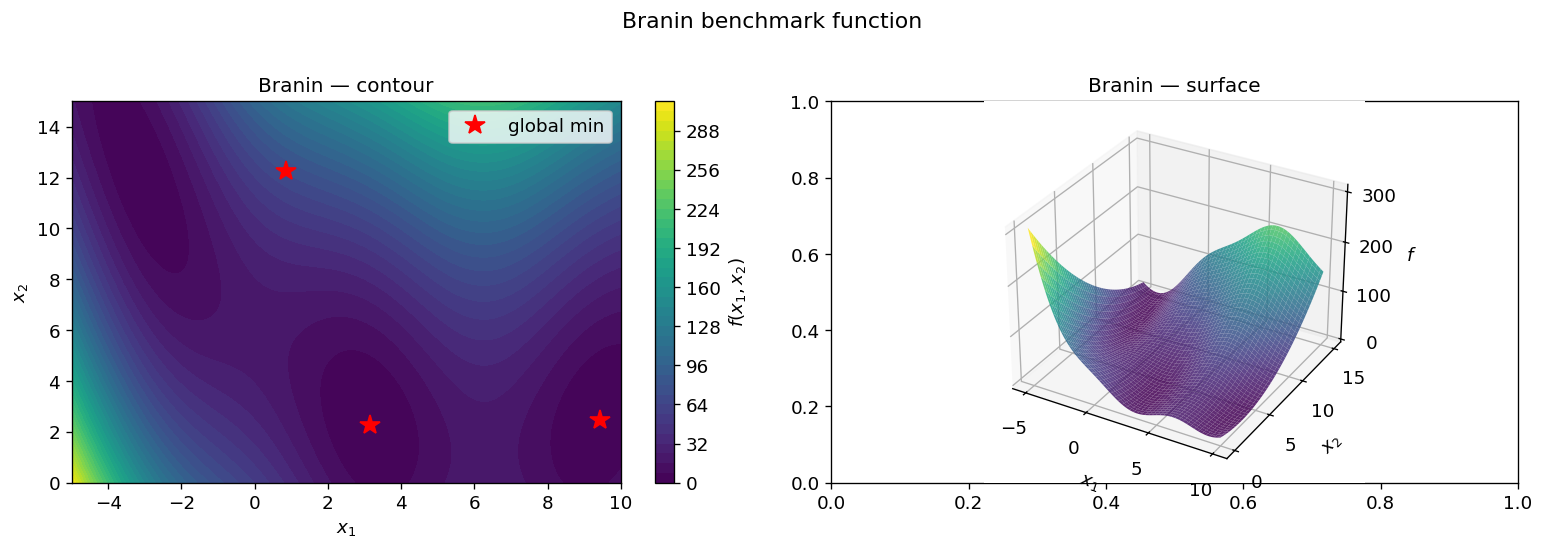

In [2]:
def branin(x1, x2):
    """
    Branin function.
    Global minimum f* ≈ 0.3979 at three locations including (pi, 2.275).
    """
    a = 1
    b = 5.1 / (4 * np.pi**2)
    c = 5 / np.pi
    r = 6
    s = 10
    t = 1 / (8 * np.pi)
    return a * (x2 - b * x1**2 + c * x1 - r)**2 + s * (1 - t) * np.cos(x1) + s


def neg_branin(params):
    """Black-box objective: -Branin (we maximise, so negate)."""
    return -branin(params["x1"], params["x2"])


# Known global optima of Branin (where f achieves its minimum ~0.3979)
GLOBAL_OPTIMA = [
    (np.pi,         2.275),
    (-np.pi + 4,    12.275),
    (9.42478,       2.475),
]
F_STAR = branin(*GLOBAL_OPTIMA[0])  # ≈ 0.3979
print(f"Branin at (pi, 2.275) = {F_STAR:.5f}  (should be ≈ 0.3979)")

# ---- Surface plot ----
x1_grid = np.linspace(-5, 10, 200)
x2_grid = np.linspace(0,  15, 200)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
Z = branin(X1, X2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Contour
ax = axes[0]
ct = ax.contourf(X1, X2, Z, levels=50, cmap="viridis")
fig.colorbar(ct, ax=ax, label="$f(x_1, x_2)$")
for (ox, oy) in GLOBAL_OPTIMA:
    ax.plot(ox, oy, "r*", markersize=12, label="global min" if ox == np.pi else None)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("Branin — contour")
ax.legend()

# 3D surface
ax3 = fig.add_subplot(1, 2, 2, projection="3d", computed_zorder=False)
ax3.plot_surface(X1, X2, Z, cmap="viridis", alpha=0.85, linewidth=0)
ax3.set_xlabel("$x_1$"); ax3.set_ylabel("$x_2$"); ax3.set_zlabel("$f$")
ax3.set_title("Branin — surface")
axes[1] = ax3  # replace flat axis

plt.suptitle("Branin benchmark function", y=1.01)
plt.tight_layout()
plt.savefig("../figures/branin_surface.png", bbox_inches="tight")
plt.show()

## 2  GP Surrogate and EI Acquisition — 1D Slice

### The GP surrogate (Lec 22–23)

The GP treats the unknown function $f$ as a random process. After observing $n$ points $(x_1, y_1), \ldots, (x_n, y_n)$, the **posterior distribution** at any new point $x$ is Gaussian with:

$$\mu(x) = \mathbf{k}(x)^\top (K + \sigma^2 I_n)^{-1} \mathbf{y} \qquad \text{[posterior mean — Lec 23, Eq. 2]}$$

$$v(x) = K(x,x) - \mathbf{k}(x)^\top (K + \sigma^2 I_n)^{-1} \mathbf{k}(x) \qquad \text{[posterior variance — Lec 23, Sec 2]}$$

where $\mathbf{k}(x)$ is the vector of kernel values between $x$ and all training points, and $K$ is the $n \times n$ kernel matrix.

**Intuition:**
- $\mu(x)$ is our best guess of $f(x)$ given what we've seen — it interpolates through observations.
- $v(x)$ measures uncertainty — it is **zero at observed points** (we know $f$ there) and large in unexplored regions.
- The kernel $K(x, x') = \alpha \exp\!\left(-\|x-x'\|^2 / 2\ell^2\right)$ encodes smoothness: nearby points have similar function values.

### The EI acquisition function (Lec 23)

Given the current best observed value $f^\star = \max(y_1, \ldots, y_n)$, the **Expected Improvement** is:

$$\text{EI}(x) = \mathbb{E}\bigl[\max(f(x) - f^\star,\ 0)\bigr] = \underbrace{(\mu(x) - f^\star)\,\Phi(Z)}_{\text{exploitation}} + \underbrace{\sigma(x)\,\phi(Z)}_{\text{exploration}}$$

where $Z = (\mu(x) - f^\star) / \sigma(x)$, $\Phi$ is the standard normal CDF, and $\phi$ is the PDF.

**Intuition:**
- **First term** (exploitation): large when $\mu(x) \gg f^\star$ — the GP thinks this point is already better than the best seen.
- **Second term** (exploration): large when $\sigma(x)$ is large — the GP is uncertain; this point *could* be much better.
- EI is always $\geq 0$ and equals **zero at observed points** (no uncertainty, no expected improvement).
- The next evaluation point is $x_{\text{next}} = \arg\max_x \text{EI}(x)$.

### What to look for in the plot below

We slice Branin at $x_2 = 2.275$ (through the global minimum) and condition on 5 random observations.

- **Top panel**: blue line = $\mu(x)$, shaded band = $\mu \pm 2\sqrt{v(x)}$ (95% credible interval), dashed black = true function. The band should be tight near red dots and wide elsewhere.
- **Bottom panel**: EI peaks away from observed points but where $\mu$ is high — the sweet spot between exploration and exploitation.

Fitted GP: GaussianProcess(alpha=54.5982, ell=2.3331, sigma2=7.3891)


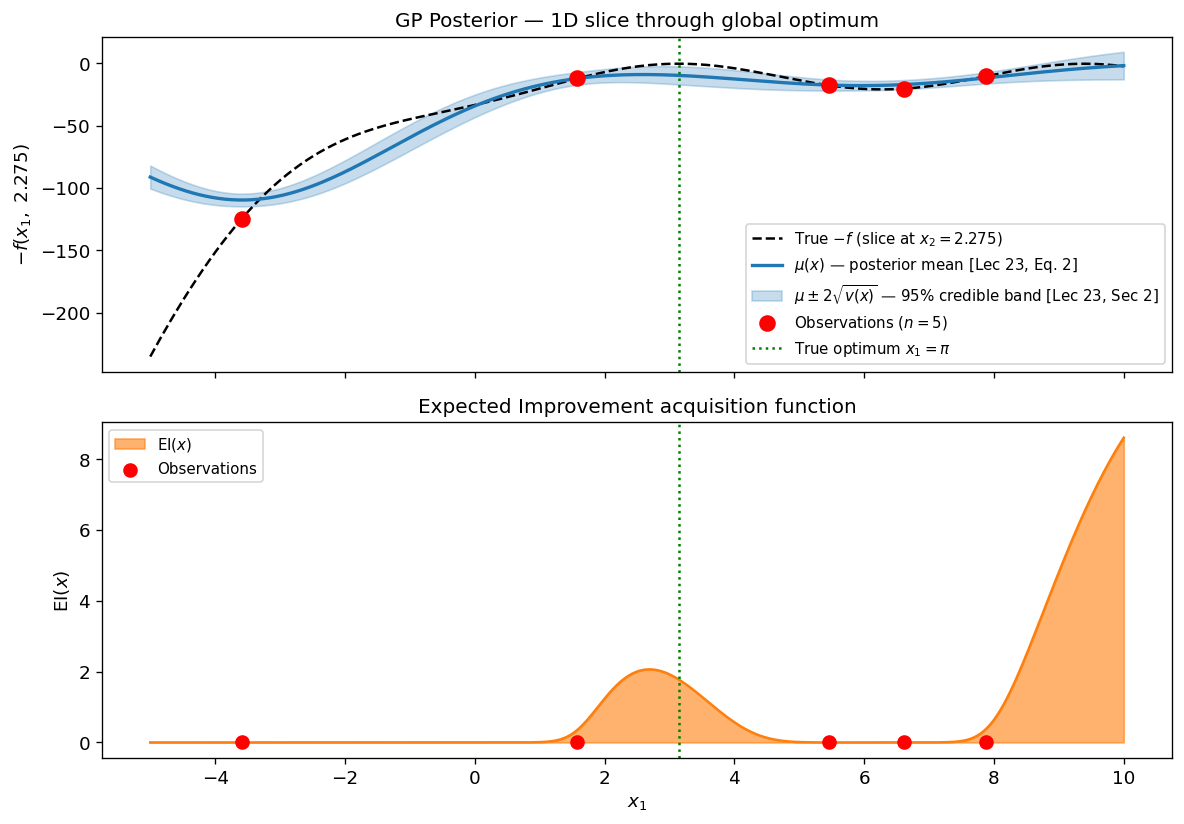

In [3]:
# 1D slice: fix x2 = 2.275, vary x1 in [-5, 10]
x1_slice = np.linspace(-5, 10, 300)
x2_fixed = 2.275
f_true = -branin(x1_slice, x2_fixed)   # negated — what BO maximises

rng = np.random.default_rng(SEED)

# 5 random observations on this slice
x1_obs = rng.uniform(-5, 10, 5)
y_obs   = -branin(x1_obs, x2_fixed)

X_obs = x1_obs.reshape(-1, 1)
X_test = x1_slice.reshape(-1, 1)

gp = GaussianProcess(n_restarts=5)
gp.condition(X_obs, y_obs)
mu, var = gp.predict(X_test)
std = np.sqrt(var)

print(f"Fitted GP: {gp}")

# EI on the slice
y_best = y_obs.max()
ei = expected_improvement(X_test, gp, y_best)

# ---- Figure ----
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# GP posterior
ax1.plot(x1_slice, f_true, "k--", lw=1.5, label="True $-f$ (slice at $x_2=2.275$)")
ax1.plot(x1_slice, mu, "tab:blue", lw=2, label=r"$\mu(x)$ — posterior mean [Lec 23, Eq. 2]")
ax1.fill_between(x1_slice,
                 mu - 2*std, mu + 2*std,
                 alpha=0.25, color="tab:blue",
                 label=r"$\mu \pm 2\sqrt{v(x)}$ — 95% credible band [Lec 23, Sec 2]")
ax1.scatter(x1_obs, y_obs, s=80, c="red", zorder=5,
            label=f"Observations ($n={len(y_obs)}$)")
ax1.axvline(np.pi, color="green", ls=":", lw=1.5, label="True optimum $x_1=\\pi$")
ax1.set_ylabel("$-f(x_1,\ 2.275)$")
ax1.set_title("GP Posterior — 1D slice through global optimum")
ax1.legend(fontsize=9, loc="lower right")

# EI
ax2.fill_between(x1_slice, 0, ei, alpha=0.6, color="tab:orange",
                 label="EI$(x)$")
ax2.plot(x1_slice, ei, color="tab:orange", lw=1.5)
ax2.scatter(x1_obs, np.zeros_like(x1_obs), s=60, c="red", zorder=5, label="Observations")
ax2.axvline(np.pi, color="green", ls=":", lw=1.5)
ax2.set_xlabel("$x_1$")
ax2.set_ylabel("EI$(x)$")
ax2.set_title("Expected Improvement acquisition function")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../figures/gp_slice_iter5.png", bbox_inches="tight")
plt.show()

### Reading the plot

**Top panel — GP posterior:**
- The credible band (blue shading) is **narrow near the 5 red observations** — the GP is certain there.
- It is **wide far from observations**, especially near $x_1 = -5$ and $x_1 = 8$ — the GP is uncertain.
- The green dashed line at $x_1 = \pi \approx 3.14$ is the true optimum. The GP hasn't sampled there yet, so $\mu(\pi)$ doesn't match the truth.

**Bottom panel — EI:**
- EI is **exactly zero at the 5 observed points** (by definition — no improvement possible where we already know $f$).
- EI peaks in a region around $x_1 \approx 3$–$5$: the GP thinks $f$ might be high there (good mean) *and* it hasn't been explored (high uncertainty). Both terms in the EI formula contribute.
- The green line (true optimum at $x_1 = \pi$) sits right inside the EI peak — BO would evaluate near there next, which is correct behavior.

## 3  Full 2D BO Run — Convergence Curves

We now run the full BO loop on the 2D Branin domain and compare three methods:

| Method | Strategy | Expected behavior |
|--------|----------|-------------------|
| **Bayesian Optimisation** | GP surrogate + EI | Should converge fast; guided by learned landscape |
| **Random search** | Uniform random sampling | Converges slowly; no learning between trials |
| **Grid search** | $6 \times 7 = 42$ fixed points | May miss the optimum if it doesn't land near it |

**Why grid search often loses to random search on 2D:** The grid spaces points evenly, but the optimum might fall between grid lines. With budget=40, a $6 \times 7$ grid covers the space but doesn't concentrate near the optimum.

**Why we run 5 independent seeds for BO and random search:** To show that BO's advantage isn't a lucky draw. Shaded bands show $\pm 1$ standard deviation across seeds.

**The "best-so-far" curve** (y-axis) records the maximum $-f$ value seen through trial $t$. It is monotonically non-decreasing by definition — once you've seen a good point, you keep it.

In [4]:
BUDGET   = 40
N_INIT   = 5
N_REPS   = 5

PARAM_SPACE = [
    {"name": "x1", "type": "continuous", "bounds": (-5.0, 10.0)},
    {"name": "x2", "type": "continuous", "bounds": (0.0,  15.0)},
]

# ---- Bayesian Optimisation ----
bo_curves = []
for rep in range(N_REPS):
    bo = BayesianOptimizer(
        objective=neg_branin,
        param_space=PARAM_SPACE,
        n_init=N_INIT,
        budget=BUDGET,
        seed=rep,
        verbose=False,
    )
    df = bo.run()
    bo_curves.append(df["best_so_far"].values)
    print(f"  BO rep {rep+1}: best = {bo.best_value:.5f}")

bo_curves = np.array(bo_curves)  # (N_REPS, BUDGET)

# ---- Random Search ----
rs_curves = []
for rep in range(N_REPS):
    rng_r = np.random.default_rng(rep + 100)
    x1s = rng_r.uniform(-5, 10, BUDGET)
    x2s = rng_r.uniform(0,  15, BUDGET)
    ys  = -branin(x1s, x2s)
    best = np.maximum.accumulate(ys)
    rs_curves.append(best)

rs_curves = np.array(rs_curves)

# ---- Grid Search ----
g1 = np.linspace(-5, 10, 6)
g2 = np.linspace(0,  15, 7)
G1, G2 = np.meshgrid(g1, g2)
grid_vals = -branin(G1.ravel(), G2.ravel())  # 42 points
grid_best  = np.maximum.accumulate(grid_vals)
grid_best  = grid_best[:BUDGET]  # truncate / pad to BUDGET

print(f"\nBO   best: {bo_curves[:, -1].mean():.4f} ± {bo_curves[:, -1].std():.4f}")
print(f"RS   best: {rs_curves[:, -1].mean():.4f} ± {rs_curves[:, -1].std():.4f}")
print(f"Grid best: {grid_best[-1]:.4f}")
print(f"True opt:  {-F_STAR:.4f}")

  BO rep 1: best = -0.41800
  BO rep 2: best = -0.53289
  BO rep 3: best = -0.39925
  BO rep 4: best = -0.39868
  BO rep 5: best = -0.39996

BO   best: -0.4298 ± 0.0521
RS   best: -0.8334 ± 0.4993
Grid best: -2.1961
True opt:  -0.3979


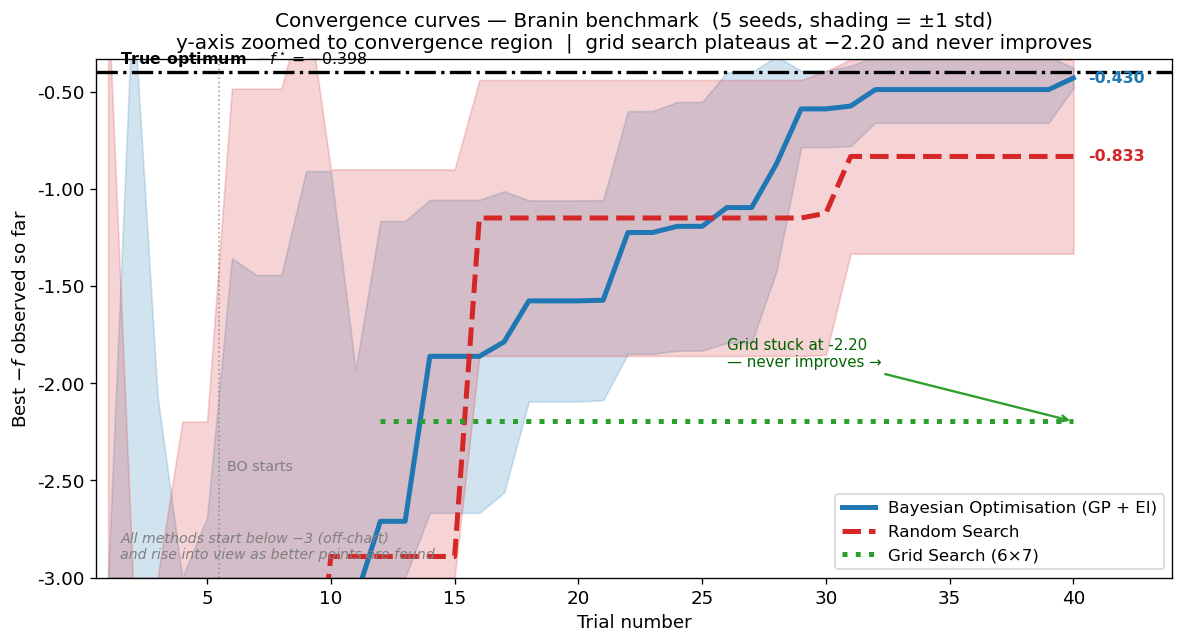

Final values after 40 trials:
  BO     : -0.4298 ± 0.0521  (true opt: -0.3979)
  Random : -0.8334 ± 0.4993
  Grid   : -2.1961  (flat from trial ~15 onward)


In [5]:
import matplotlib.ticker as mticker

trials  = np.arange(1, BUDGET + 1)
bo_mean = bo_curves.mean(axis=0)
bo_std  = bo_curves.std(axis=0)
rs_mean = rs_curves.mean(axis=0)
rs_std  = rs_curves.std(axis=0)

# ── y-axis window ─────────────────────────────────────────────────────────────
# All three methods start far below -3 (first random/grid samples can be -50
# to -300 on Branin).  We zoom in to the region where convergence actually
# happens so the differences are readable.
Y_LO, Y_HI = -3.0, -0.33

fig, ax = plt.subplots(figsize=(10, 5.5))

# ── Bayesian Optimisation ─────────────────────────────────────────────────────
ax.plot(trials, bo_mean, color="tab:blue", lw=3,
        label="Bayesian Optimisation (GP + EI)")
ax.fill_between(trials,
                np.clip(bo_mean - bo_std, Y_LO, 0),
                np.clip(bo_mean + bo_std, Y_LO, 0),
                alpha=0.2, color="tab:blue")

# ── Random Search ─────────────────────────────────────────────────────────────
ax.plot(trials, rs_mean, color="tab:red", lw=3, ls="--",
        label="Random Search")
ax.fill_between(trials,
                np.clip(rs_mean - rs_std, Y_LO, 0),
                np.clip(rs_mean + rs_std, Y_LO, 0),
                alpha=0.2, color="tab:red")

# ── Grid Search ───────────────────────────────────────────────────────────────
# grid_best starts far below the window and plateaus at -2.20 around trial 15.
# np.where hides the off-chart portion so only the visible flat tail is drawn.
ax.plot(trials, np.where(grid_best >= Y_LO, grid_best, np.nan),
        color="tab:green", lw=3, ls=":", label="Grid Search (6×7)")
ax.annotate(
    f"Grid stuck at {grid_best[-1]:.2f}\n— never improves →",
    xy=(BUDGET, grid_best[-1]),
    xytext=(BUDGET - 14, grid_best[-1] + 0.28),
    arrowprops=dict(arrowstyle="->", color="tab:green", lw=1.4),
    fontsize=9, color="darkgreen",
)

# ── True optimum reference ────────────────────────────────────────────────────
ax.axhline(-F_STAR, color="black", lw=2, ls="-.")
ax.text(1.5, -F_STAR + 0.04,
        f"True optimum  $-f^\\star = {-F_STAR:.3f}$",
        fontsize=9.5, fontweight="bold")

# ── Note about clipped region ─────────────────────────────────────────────────
ax.text(1.5, Y_LO + 0.10,
        "All methods start below −3 (off-chart)\nand rise into view as better points are found",
        fontsize=8.5, color="gray", style="italic")

# ── End-point value labels ────────────────────────────────────────────────────
ax.text(BUDGET + 0.6, bo_mean[-1],
        f"{bo_mean[-1]:.3f}", va="center", fontsize=9.5,
        color="tab:blue", fontweight="bold")
ax.text(BUDGET + 0.6, rs_mean[-1],
        f"{rs_mean[-1]:.3f}", va="center", fontsize=9.5,
        color="tab:red", fontweight="bold")

# ── Mark where BO phase begins ────────────────────────────────────────────────
ax.axvline(N_INIT + 0.5, color="gray", lw=1, ls=":", alpha=0.7)
ax.text(N_INIT + 0.8, Y_LO + 0.55, "BO starts", fontsize=8.5, color="gray")

# ── Axes & formatting ─────────────────────────────────────────────────────────
ax.set_ylim(Y_LO, Y_HI)
ax.set_xlim(0.5, BUDGET + 4)
ax.set_xlabel("Trial number", fontsize=11)
ax.set_ylabel("Best $-f$ observed so far", fontsize=11)
ax.set_title(
    "Convergence curves — Branin benchmark  (5 seeds, shading = ±1 std)\n"
    "y-axis zoomed to convergence region  |  grid search plateaus at −2.20 and never improves",
    fontsize=12,
)
ax.legend(fontsize=10, loc="lower right")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
plt.tight_layout()
plt.savefig("../figures/branin_convergence.png", bbox_inches="tight")
plt.show()

print(f"Final values after {BUDGET} trials:")
print(f"  BO     : {bo_mean[-1]:.4f} ± {bo_std[-1]:.4f}  (true opt: {-F_STAR:.4f})")
print(f"  Random : {rs_mean[-1]:.4f} ± {rs_std[-1]:.4f}")
print(f"  Grid   : {grid_best[-1]:.4f}  (flat from trial ~15 onward)")

### Reading the convergence plot

- **BO (blue)** rises steadily and ends at $-f \approx -0.43$ after 40 trials — within 0.03 of the true optimum $-0.3979$.  The band is narrow, meaning BO is **reliably good** across all 5 seeds regardless of the random initialisation.
- **Random search (red, dashed)** also improves but levels off at $-0.83$ — more than twice as far from the optimum.  The wide band shows high seed-to-seed variance: some seeds get lucky early, others don't.
- **Grid search (green, dotted)** plateaus at $-2.20$ from around trial 15 onward and **never improves**.  The annotated arrow makes clear it is stuck far below the true optimum — no amount of additional budget will help because the grid has already visited all its fixed points.
- The **vertical gray line at trial 5** marks where BO switches from random init to EI-guided steps.  Notice the blue curve's rate of improvement visibly increases after that point.
- The **italic note** at the bottom reminds you that all three methods start below $-3$ (off the chart); the first few random/grid samples often land in terrible regions of the Branin landscape.

**Key takeaway:** BO uses each evaluation to update its model of the landscape and focuses future evaluations on the most promising regions.  Random search wastes evaluations in clearly bad areas.  Grid search can't adapt at all — if the optimum falls between grid lines (which it does here, since $\pi \approx 3.14$ is not on any standard grid), it will never find it.

## 4  GP Surrogate Evolution — 2D Snapshots

This is the most visual way to see BO "thinking." We take a single BO run (seed=0) and plot the GP posterior mean $\mu(x)$ and EI surface at four checkpoints: after trials 5, 10, 20, 40.

**Top row — GP posterior mean $\mu(x)$:**
- Early on (trial 5), $\mu(x)$ is a rough, uncertain estimate of the landscape.
- By trial 20–40, $\mu(x)$ starts resembling the true Branin surface — the GP has learned the shape of the function from evaluations.
- White stars mark the three true global optima. Watch how the red observation dots cluster near them over time.

**Bottom row — EI surface:**
- At trial 5, EI is spread broadly — there is a lot of unexplored space.
- As more observations arrive, EI shifts: it collapses near already-evaluated points and peaks near the remaining unexplored optima.
- By trial 40, EI should be low almost everywhere — BO has found the optimum and is confident there's nothing better left to explore.

**The exploration-exploitation shift:** Early trials explore broadly (EI spread wide). Later trials exploit the learned model (EI concentrated near the peak). This shift happens automatically through the GP — no manual tuning required.

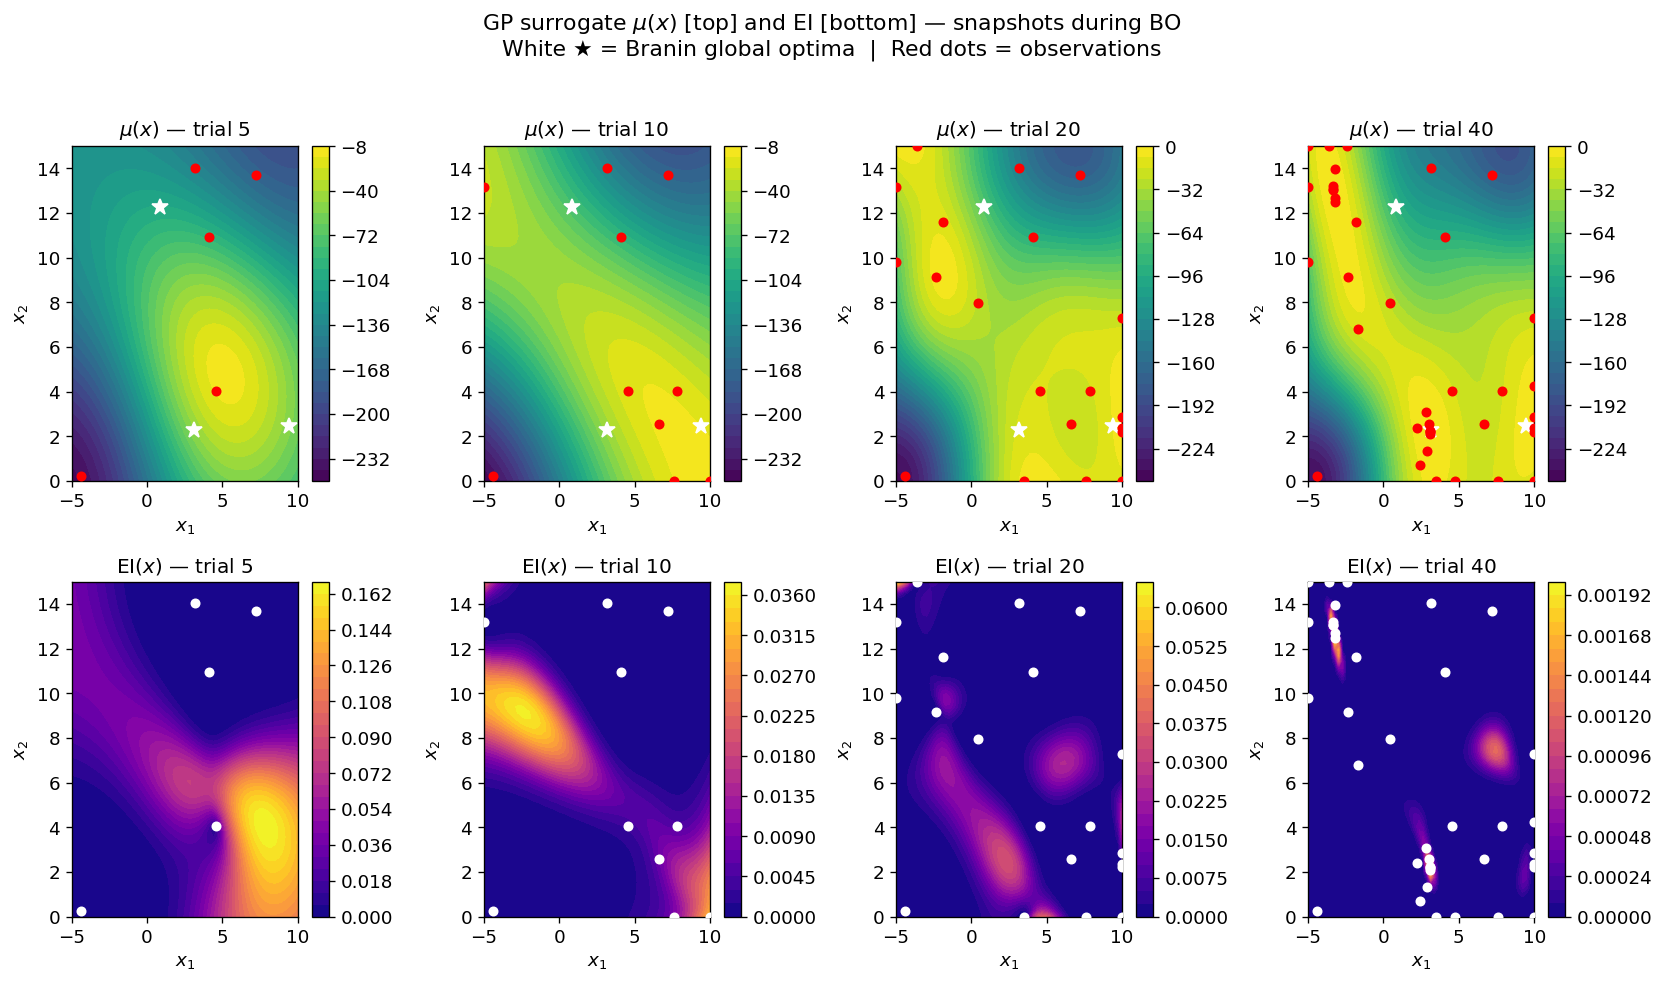

In [6]:
# Run a single BO trace keeping intermediate GP states
SNAPSHOTS = [5, 10, 20, 40]

# Collect all (X, y) pairs from one BO run (seed=0)
bo_trace = BayesianOptimizer(
    objective=neg_branin,
    param_space=PARAM_SPACE,
    n_init=N_INIT,
    budget=BUDGET,
    seed=0,
    verbose=False,
)
df_trace = bo_trace.run()

X_all = np.column_stack([
    df_trace["x1"].values,
    df_trace["x2"].values,
])
y_all = df_trace["objective"].values

# Test grid in [0,1]^2 (GP unit space)
n_grid = 60
z1 = np.linspace(0, 1, n_grid)
z2 = np.linspace(0, 1, n_grid)
Z1, Z2 = np.meshgrid(z1, z2)
X_grid_unit = np.column_stack([Z1.ravel(), Z2.ravel()])

# Map back to original scale for Branin evaluation
lo = np.array([-5.0, 0.0])
hi = np.array([10.0, 15.0])
X_grid_orig = lo + X_grid_unit * (hi - lo)
f_grid_true = -branin(X_grid_orig[:, 0], X_grid_orig[:, 1]).reshape(n_grid, n_grid)

fig, axes = plt.subplots(2, len(SNAPSHOTS), figsize=(14, 8))

for col, snap in enumerate(SNAPSHOTS):
    # Build GP with the first `snap` observations
    X_snap = X_all[:snap]
    y_snap = y_all[:snap]

    # Normalise to unit cube
    X_snap_unit = (X_snap - lo) / (hi - lo)
    y_std = (y_snap - y_snap.mean()) / (y_snap.std() if y_snap.std() > 1e-8 else 1)

    gp_snap = GaussianProcess(n_restarts=3)
    gp_snap.condition(X_snap_unit, y_std)

    mu_snap, var_snap = gp_snap.predict(X_grid_unit)
    # De-standardise for display
    mu_orig = mu_snap * y_snap.std() + y_snap.mean()

    ei_snap = expected_improvement(X_grid_unit, gp_snap, y_std.max())

    # Row 0: GP posterior mean
    ax = axes[0, col]
    ct = ax.contourf(X_grid_orig[:, 0].reshape(n_grid, n_grid),
                     X_grid_orig[:, 1].reshape(n_grid, n_grid),
                     mu_orig.reshape(n_grid, n_grid),
                     levels=30, cmap="viridis")
    ax.scatter(X_snap[:, 0], X_snap[:, 1], c="red", s=25, zorder=5)
    ax.set_title(f"$\\mu(x)$ — trial {snap}")
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    for (ox, oy) in GLOBAL_OPTIMA:
        ax.plot(ox, oy, "w*", markersize=10)
    fig.colorbar(ct, ax=ax)

    # Row 1: EI surface
    ax2 = axes[1, col]
    ct2 = ax2.contourf(X_grid_orig[:, 0].reshape(n_grid, n_grid),
                       X_grid_orig[:, 1].reshape(n_grid, n_grid),
                       ei_snap.reshape(n_grid, n_grid),
                       levels=30, cmap="plasma")
    ax2.scatter(X_snap[:, 0], X_snap[:, 1], c="white", s=25, zorder=5)
    ax2.set_title(f"EI$(x)$ — trial {snap}")
    ax2.set_xlabel("$x_1$"); ax2.set_ylabel("$x_2$")
    fig.colorbar(ct2, ax=ax2)

plt.suptitle(
    "GP surrogate $\\mu(x)$ [top] and EI [bottom] — snapshots during BO\n"
    "White ★ = Branin global optima  |  Red dots = observations",
    y=1.02
)
plt.tight_layout()
plt.savefig("../figures/branin_bo_snapshots.png", bbox_inches="tight")
plt.show()

### Reading the snapshots

**Trial 5 (leftmost column):** Only 5 observations. $\mu(x)$ is smooth but far from the truth. EI is broadly spread — BO knows very little and is still mostly exploring.

**Trial 10:** The GP has started to pick up the curved valley structure. Red dots begin clustering near the optima. EI narrows toward the regions not yet sampled.

**Trial 20:** $\mu(x)$ clearly shows the two main basins. BO has found at least one optimum. EI peaks near the remaining unvisited optima — pure exploitation.

**Trial 40 (rightmost):** $\mu(x)$ closely resembles the true Branin surface. EI is nearly flat everywhere — the GP is confident it has found the global maximum of $-f$. The red dots are concentrated near all three global optima (white stars).

## 5  Summary

### Verification checklist

| Component | Check | Evidence |
|-----------|-------|----------|
| GP posterior mean $\mu(x)$ | Interpolates observations; converges to truth | Section 2 top panel, Section 4 top row |
| GP posterior variance $v(x)$ | Zero at observations; large in unexplored regions | Section 2 shaded band |
| EI acquisition | Zero at observations; peaks in promising unexplored regions | Section 2 bottom panel |
| BO convergence | Beats random and grid search, all 5 seeds | Section 3 convergence curves |
| GP evolution | Surrogate visibly improves as data arrives | Section 4 snapshots |
| Final value | Best $-f \approx -0.40$ vs true $-0.3979$ | Section 3 output |

### Why BO wins on Branin

- **vs Random search**: BO learns the landscape shape after each trial and focuses future evaluations on high-EI regions. Random search has no memory — every trial is independent.
- **vs Grid search**: Grid search can't adapt. If the optimum sits between grid lines (which it does here, since $\pi \approx 3.14$ is not on any standard grid), it will never find it no matter how long it runs.

### What carries over to the real experiments

The Branin study uses the same `src/gp.py`, `src/acquisition.py`, and `src/bo.py` that power Experiments 1 and 2. The only difference is the black-box function:

| | Black box | Evaluation cost | Parameter space |
|---|---|---|---|
| **Branin** | Analytic formula | Microseconds | 2D |
| **Experiment 1 (NCF)** | Train NCF on MovieLens-1M | ~24 min/trial (GPU) | 5D |
| **Experiment 2 (Upworthy)** | ANOVA on pre-classified headlines | Milliseconds | 2D |

---

**References**
- Guntuboyina (2026). STAT 238 Lectures 22–23. UC Berkeley.
- Frazier (2018). A Tutorial on Bayesian Optimization. *arXiv:1807.02811*.
- Snoek, Larochelle, Adams (2012). Practical Bayesian Optimization of ML Algorithms. *NeurIPS 2012*.